#📌 Extracción

In [1]:
import pandas as pd
import requests

In [2]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

In [3]:
response = requests.get(url)
data = response.json()

In [4]:
df = pd.DataFrame(data)

In [5]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [7]:
df.iloc[0]

,0
customerID,0002-ORFBO
Churn,No
customer,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part..."
phone,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}"
internet,"{'InternetService': 'DSL', 'OnlineSecurity': '..."
account,"{'Contract': 'One year', 'PaperlessBilling': '..."


In [8]:
df.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

#🔧 Transformación

In [10]:
df_normalizado = pd.json_normalize(data)

In [11]:
df_normalizado.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [12]:
df_normalizado.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [13]:
df_normalizado.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


In [14]:
df_normalizado['account.Charges.Total'].head()

,account.Charges.Total
0,593.3
1,542.4
2,280.85
3,1237.85
4,267.4


In [15]:
df_normalizado['account.Charges.Total'].unique()

array(['593.3', '542.4', '280.85', ..., '742.9', '4627.65', '3707.6'],
      dtype=object)

In [16]:
df_normalizado['account.Charges.Total'].value_counts()

,count
account.Charges.Total,
20.2,11
,11
19.75,9
19.55,9
19.9,9
...,...
1993.2,1
72.1,1
1237.85,1


In [17]:
df_normalizado[['account.Charges.Monthly','account.Charges.Total']].describe()

,account.Charges.Monthly
count,7267.000000
mean,64.720098
std,30.129572
min,18.250000
25%,35.425000
50%,70.300000
75%,89.875000
max,118.750000


In [18]:
df_normalizado.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


In [20]:
df_normalizado['account.Charges.Total'] = pd.to_numeric(
    df_normalizado['account.Charges.Total'],
    errors='coerce'
)

In [21]:
df_normalizado.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


In [25]:
df_normalizado.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [26]:
df_normalizado['calculo_total'] = (
    df_normalizado['account.Charges.Monthly'] *
    df_normalizado['customer.tenure']
)

In [27]:
df_normalizado[['account.Charges.Total','calculo_total']].head()

,account.Charges.Total,calculo_total
0,593.30,590.4
1,542.40,539.1
2,280.85,295.6
3,1237.85,1274.0
4,267.40,251.7


In [30]:
df_normalizado['Cuentas_Diarias'] = df_normalizado['account.Charges.Monthly'] / 30

In [32]:
df_normalizado.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,calculo_total,diferencia,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,One year,Yes,Mailed check,65.6,593.30,590.4,2.90,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,539.1,3.30,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,295.6,-14.75,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,1274.0,-36.15,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,251.7,15.70,2.796667


In [34]:
##convertimos a variables binarias

columnas_binarias = [
    'Churn',
    'customer.Partner',
    'customer.Dependents',
    'phone.PhoneService',
    'account.PaperlessBilling'
]

In [36]:
df_normalizado[columnas_binarias] = df_normalizado[columnas_binarias].replace({
    'Yes': 1,
    'No': 0
}).infer_objects(copy=False)

In [37]:
df_normalizado.columns = df_normalizado.columns.str.replace('.', '_')

In [38]:
df_normalizado.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,calculo_total,diferencia,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,Yes,No,One year,1,Mailed check,65.6,593.30,590.4,2.90,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,539.1,3.30,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,No,No,Month-to-month,1,Electronic check,73.9,280.85,295.6,-14.75,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,1274.0,-36.15,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,251.7,15.70,2.796667


In [39]:
df_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   int64  
 5   customer_Dependents        7267 non-null   int64  
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   int64  
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

#📊 Carga y análisis

In [40]:
df_normalizado.describe()

,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,account_PaperlessBilling,account_Charges_Monthly,account_Charges_Total,calculo_total,diferencia,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000,7256.000000,7267.000000
mean,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2280.634213,2277.033563,0.148698,2.157337
std,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,2268.632997,2266.544961,67.131787,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000,-370.850000,0.608333
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,400.225000,393.900000,-28.550000,1.180833
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1391.000000,1389.500000,0.000000,2.343333
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,3785.300000,3782.450000,28.700000,2.995833
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,8550.000000,373.250000,3.958333


In [42]:
df_normalizado['customer_tenure'].describe()

,customer_tenure
count,7267.000000
mean,32.346498
std,24.571773
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


In [43]:
df_normalizado['account_Charges_Monthly'].describe()

,account_Charges_Monthly
count,7267.000000
mean,64.720098
std,30.129572
min,18.250000
25%,35.425000
50%,70.300000
75%,89.875000
max,118.750000


In [44]:
df_normalizado['account_Charges_Total'].describe()

,account_Charges_Total
count,7256.000000
mean,2280.634213
std,2268.632997
min,18.800000
25%,400.225000
50%,1391.000000
75%,3785.300000
max,8684.800000


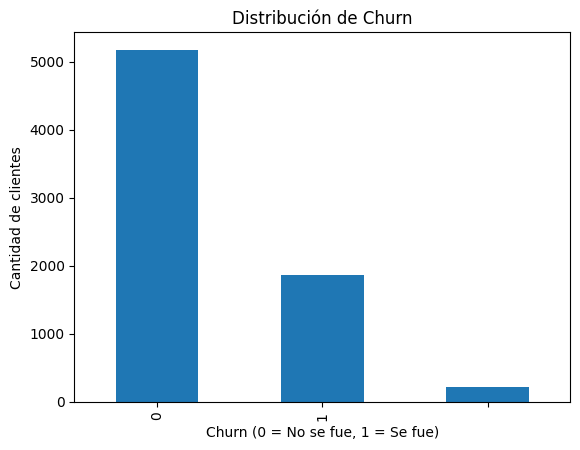

In [47]:
import matplotlib.pyplot as plt

df_normalizado['Churn'].value_counts().plot(kind='bar')

plt.title('Distribución de Churn')
plt.xlabel('Churn (0 = No se fue, 1 = Se fue)')
plt.ylabel('Cantidad de clientes')

plt.show()

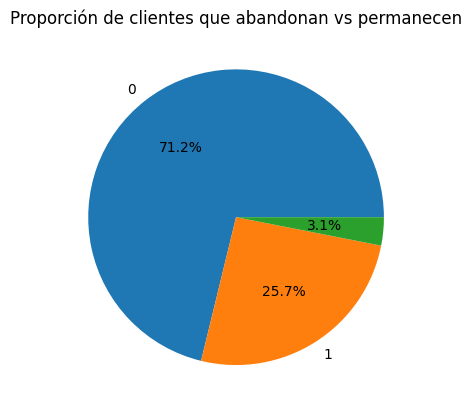

In [48]:
df_normalizado['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Proporción de clientes que abandonan vs permanecen')
plt.ylabel('')

plt.show()

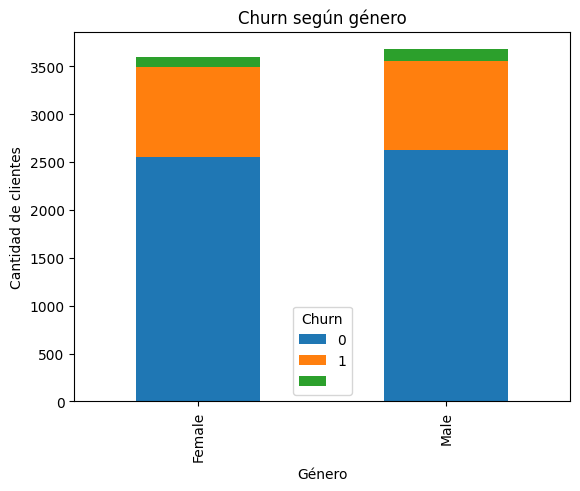

In [49]:
churn_genero = pd.crosstab(df_normalizado['customer_gender'], df_normalizado['Churn'])

churn_genero.plot(kind='bar', stacked=True)

plt.title('Churn según género')
plt.xlabel('Género')
plt.ylabel('Cantidad de clientes')

plt.show()

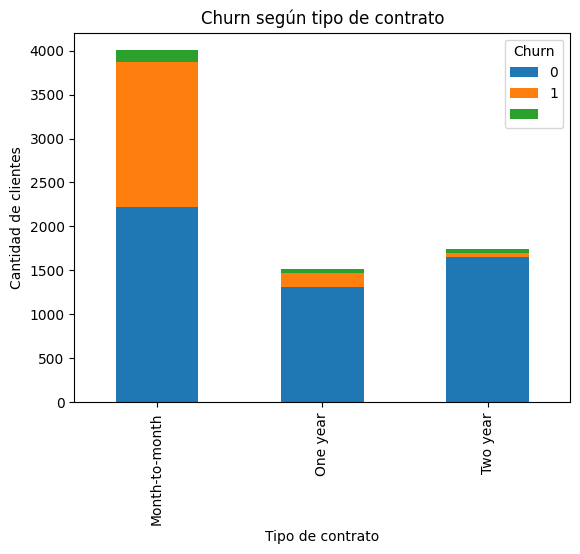

In [50]:
churn_contrato = pd.crosstab(df_normalizado['account_Contract'], df_normalizado['Churn'])

churn_contrato.plot(kind='bar', stacked=True)

plt.title('Churn según tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad de clientes')

plt.show()

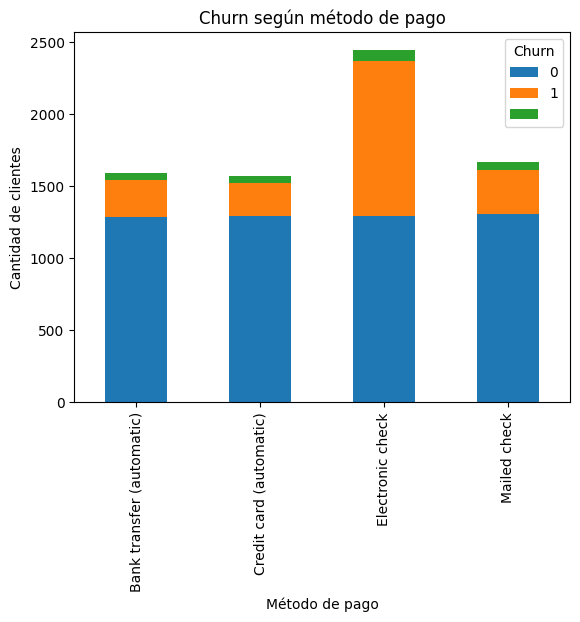

In [51]:
churn_pago = pd.crosstab(df_normalizado['account_PaymentMethod'], df_normalizado['Churn'])

churn_pago.plot(kind='bar', stacked=True)

plt.title('Churn según método de pago')
plt.xlabel('Método de pago')
plt.ylabel('Cantidad de clientes')

plt.show()

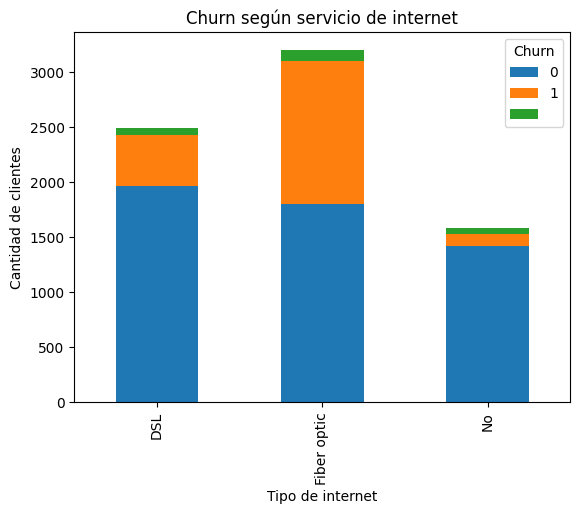

In [52]:
churn_internet = pd.crosstab(df_normalizado['internet_InternetService'], df_normalizado['Churn'])

churn_internet.plot(kind='bar', stacked=True)

plt.title('Churn según servicio de internet')
plt.xlabel('Tipo de internet')
plt.ylabel('Cantidad de clientes')

plt.show()

#📄Informe final

Informe Final – Análisis de Evasión de Clientes
Introducción

El objetivo de este análisis fue estudiar el fenómeno de evasión de clientes (Churn) en la empresa Telecom X. La evasión ocurre cuando un cliente decide cancelar el servicio contratado, lo que representa una pérdida para la empresa. Analizar los factores asociados al abandono de clientes permite identificar patrones y desarrollar estrategias para mejorar la retención.

Para este análisis se utilizó un conjunto de datos que contiene información sobre características demográficas de los clientes, servicios contratados, condiciones de contrato y cargos asociados.

Limpieza y Tratamiento de Datos

Durante esta etapa se realizaron varias acciones para preparar los datos para el análisis. Primero se importaron los datos desde una API en formato JSON y se convirtieron en un DataFrame utilizando Python y la librería Pandas.

Posteriormente se normalizaron las estructuras anidadas del archivo JSON para obtener columnas más claras y utilizables. También se revisaron valores nulos e inconsistencias dentro del conjunto de datos.

Se transformaron variables categóricas binarias como "Yes" y "No" en valores numéricos (1 y 0) para facilitar el análisis. Además, se estandarizaron los nombres de las columnas reemplazando los puntos por guiones bajos, lo que facilita su manipulación dentro del código.

Finalmente, se creó una nueva variable llamada "Cuentas_Diarias", calculada a partir del cargo mensual del cliente, con el objetivo de obtener una estimación del gasto diario.

Análisis Exploratorio de Datos

Durante el análisis exploratorio se estudiaron diferentes variables para identificar patrones relacionados con la evasión de clientes.

Primero se analizó la distribución de la variable Churn para identificar la proporción de clientes que permanecen en la empresa y aquellos que cancelan el servicio. Los resultados muestran que la mayoría de los clientes permanecen en la empresa, mientras que una menor proporción decide cancelar el servicio.

Posteriormente se analizaron diferentes variables categóricas como el género del cliente, el tipo de contrato y el método de pago. Uno de los hallazgos más relevantes fue que los clientes con contratos mensuales presentan una mayor tasa de abandono en comparación con los clientes que tienen contratos de mayor duración.

También se observó que ciertos métodos de pago y la ausencia de algunos servicios adicionales pueden estar relacionados con una mayor probabilidad de abandono.

Conclusiones e Insights

A partir del análisis realizado se identificaron algunos factores asociados al abandono de clientes. Los clientes con contratos mensuales presentan una mayor tasa de evasión, mientras que los contratos de uno o dos años muestran una mayor estabilidad.

También se observó que los clientes con menor tiempo en la empresa tienen mayor probabilidad de cancelar el servicio. Asimismo, algunos cargos mensuales más altos pueden influir en la decisión de abandonar el servicio.

Estos resultados permiten identificar perfiles de clientes con mayor riesgo de evasión.

Recomendaciones

Con base en los hallazgos obtenidos se proponen algunas estrategias para reducir la evasión de clientes. Una de ellas es incentivar contratos de mayor duración mediante descuentos o beneficios adicionales.

También se recomienda fortalecer la relación con los clientes durante los primeros meses de servicio, ya que este periodo parece ser crítico para la retención.

Por último, promover servicios adicionales como soporte técnico o seguridad en línea podría aumentar el valor percibido por los clientes y reducir la probabilidad de abandono.